'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


/Users/zhuyi/FLARE_output/generated_datasets_latent_equations.pdf


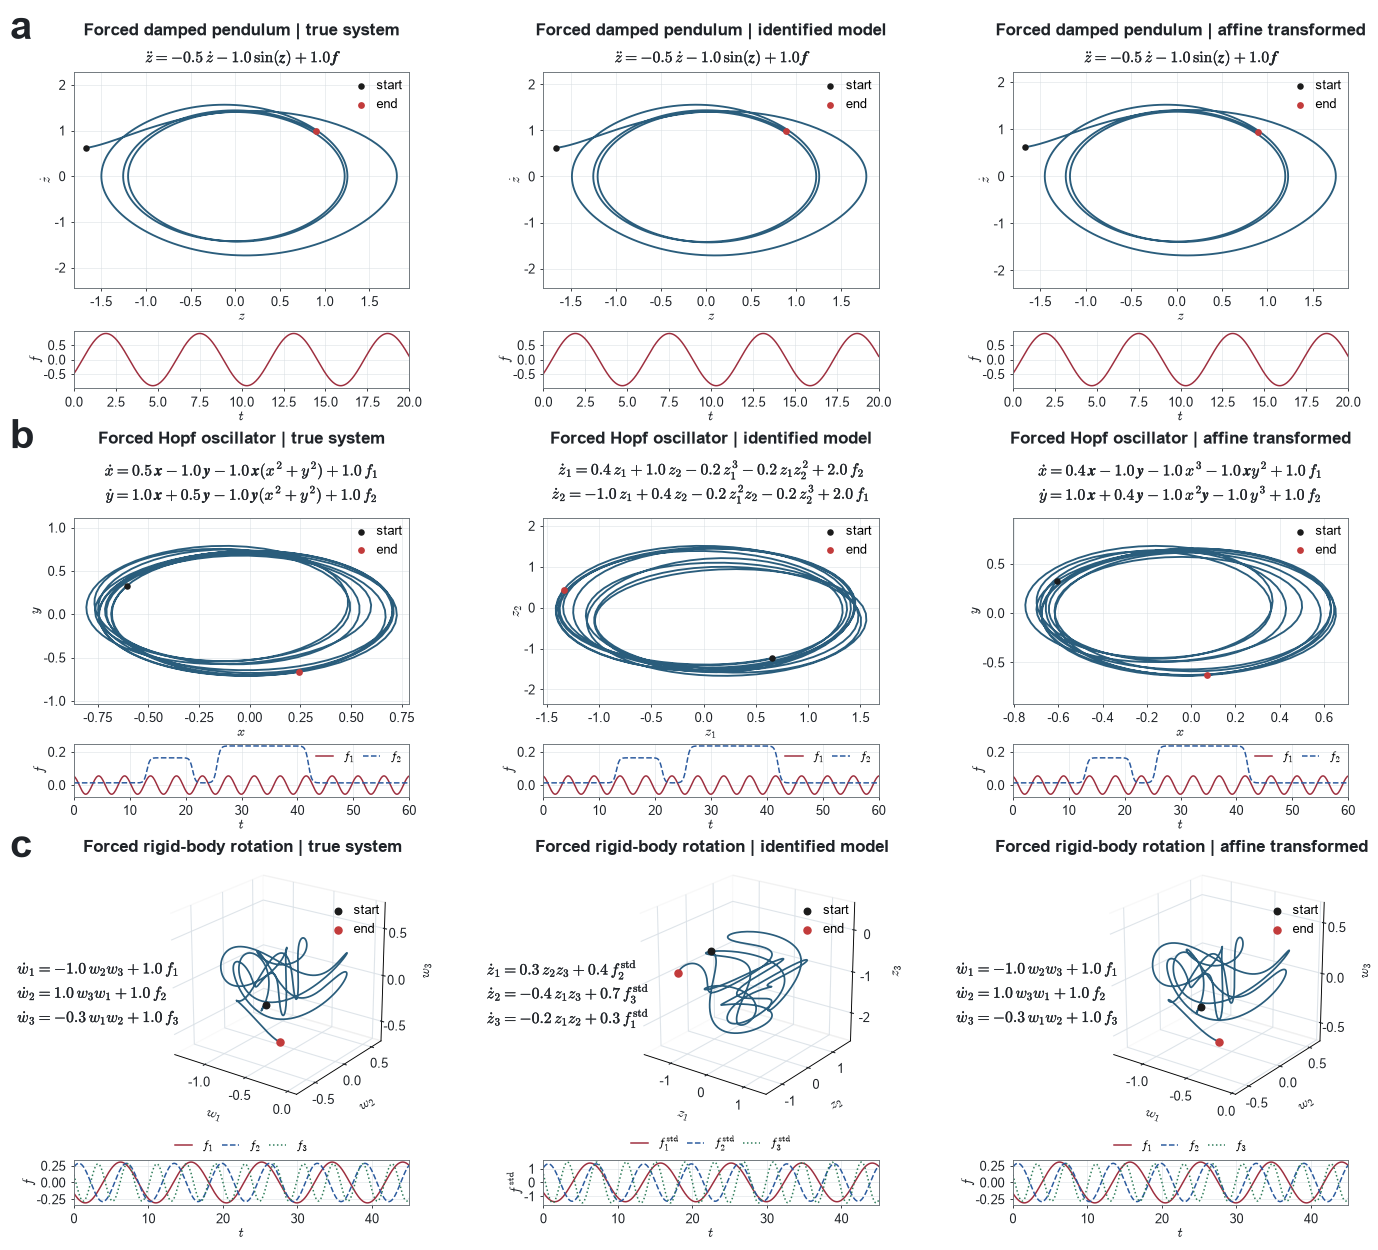

In [11]:
from __future__ import annotations

import json
import io
import re
from pathlib import Path

import matplotlib as mpl

try:
    from IPython import get_ipython
    IN_IPYTHON = get_ipython() is not None
except Exception:
    IN_IPYTHON = False

if not IN_IPYTHON:
    mpl.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as pe
from matplotlib.collections import LineCollection
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from pathlib import Path

BASE_DIR = Path("test1+test2")

if "__file__" in globals():
    OUTPUT_DIR = Path(__file__).resolve().parent
else:
    OUTPUT_DIR = Path.home() / "FLARE_output"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PDF_PATH = OUTPUT_DIR / "generated_datasets_latent_equations.pdf"
PNG_PATH = OUTPUT_DIR / "generated_datasets_latent_equations.png"

DATASETS = {
    "pend": {
        "root": BASE_DIR / "AAApend",
        "run": "tabular_window_sindy_2026_06_07_20_08_05",
        "offline": "offline_encoder_rollout_tabular_window_sindy_2026_06_07_20_08_05_best",
        "file_prefix": "pendulum",
    },
    "hpf": {
        "root": BASE_DIR / "AAAhpf",
        "run": "tabular_window_sindy_2026_06_07_22_20_21",
        "offline": "offline_encoder_rollout_tabular_window_sindy_2026_06_07_22_20_21_best",
        "file_prefix": "hopf",
    },
    "rigid": {
        "root": BASE_DIR / "AAArigid",
        "run": "tabular_window_sindy_2026_06_08_21_23_06",
        "offline": "offline_encoder_rollout_tabular_window_sindy_2026_06_08_21_23_06_best",
        "file_prefix": "rigid_body_3input",
    },
}

TRACK_COLOR = "#2A5D7C"
START_COLOR = "#1B1B1B"
END_COLOR = "#C23B3B"
FORCE_COLORS = ["#9E2F3F", "#2B5A9E", "#2D7C59"]
GRID_COLOR = "#D8DEE2"
TEXT_COLOR = "#1F2328"

# Figure-level layout.
FIGURE_SIZE = (13.6, 12.4)
OUTER_HSPACE = 0.17
OUTER_WSPACE = 0.4
FIGURE_MARGINS = dict(left=0.055, right=0.992, top=0.976, bottom=0.036)

# Typography.
TITLE_SIZE = 12.0
FORMULA_SIZE = 11.3
AXIS_LABEL_SIZE = 10.2
TICK_LABEL_SIZE = 9.4
LEGEND_SIZE = 9.0
ROW_LABEL_SIZE = 29
ROW_LABEL_X = 0.008
ROW_LABEL_Y = {"a": 1, "b": 0.67, "c": 0.34}

# Panel-internal layout.  The a row has one equation line; the b row has two.
AB_LAYOUTS = {
    "a": {
        "height_ratios": [0.23, 1.5, 0.30, 0.40],
        "hspace": 0.0,
        "y_compression": 0.68,
        "formula_y": 0.8,
    },
    "b": {
        "height_ratios": [0.53, 1.4, 0.30, 0.40],
        "hspace": 0.0,
        "y_compression": 0.68,
        "formula_y": 0.85,
    },
}
C_HEIGHT_RATIOS = [4.4, 0.78]
C_HSPACE = 0.34

# 3D axis spacing.
C_AXIS_LABELPAD = -1
C_TICK_PAD = -2
C_SPARSE_TICK_BINS = 3


def load_object_npy(path: Path) -> dict:
    arr = np.load(path, allow_pickle=True)
    if not (isinstance(arr, np.ndarray) and arr.shape == () and arr.dtype == object):
        raise ValueError(f"Expected scalar object npy: {path}")
    return arr.item()


def npz_path(dataset: str, idx: int = 1) -> Path:
    meta = DATASETS[dataset]
    return (
        meta["root"]
        / "outputs"
        / meta["offline"]
        / f"offline_prediction_{meta['file_prefix']}_{idx:03d}.npz"
    )


def test_path(dataset: str, idx: int = 1) -> Path:
    meta = DATASETS[dataset]
    return meta["root"] / "test" / f"{meta['file_prefix']}_{idx:03d}.npy"


def params_path(dataset: str) -> Path:
    meta = DATASETS[dataset]
    return meta["root"] / "outputs" / f"{meta['run']}_params.json"


def equation_path(dataset: str) -> Path:
    meta = DATASETS[dataset]
    return meta["root"] / "outputs" / meta["offline"] / "discovered_equations.txt"


def read_required_equation_files() -> dict[str, str]:
    texts = {}
    for key in DATASETS:
        path = equation_path(key)
        text = path.read_text(encoding="utf-8")
        if "Discovered latent SINDy equations" not in text:
            raise ValueError(f"Unexpected equation file content: {path}")
        texts[key] = text
    return texts


def fit_affine_from_tests(dataset: str, true_keys: list[str], n_files: int = 10) -> tuple[np.ndarray, np.ndarray]:
    """Fit true_z = learned_z @ matrix + intercept over all available test rollouts."""
    learned, true = [], []
    for idx in range(1, n_files + 1):
        pred = np.load(npz_path(dataset, idx))
        data = load_object_npy(test_path(dataset, idx))
        learned.append(np.asarray(pred["z_sindy"], dtype=float))
        true.append(np.column_stack([np.asarray(data[k], dtype=float) for k in true_keys]))

    z = np.vstack(learned)
    y = np.vstack(true)
    design = np.column_stack([z, np.ones(len(z))])
    coeff, *_ = np.linalg.lstsq(design, y, rcond=None)
    return coeff[:-1, :], coeff[-1, :]


def integrate_forced_pendulum(t: np.ndarray, z0: float, v0: float, forcing: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    def force_at(tau: float) -> float:
        return float(np.interp(tau, t, forcing[:, 0]))

    def rhs(tau: float, state: np.ndarray) -> np.ndarray:
        z, zdot = state
        return np.array([zdot, -0.5 * zdot - np.sin(z) + force_at(tau)], dtype=float)

    state = np.array([z0, v0], dtype=float)
    states = np.zeros((len(t), 2), dtype=float)
    states[0] = state
    for i in range(len(t) - 1):
        h = float(t[i + 1] - t[i])
        k1 = rhs(float(t[i]), state)
        k2 = rhs(float(t[i]) + 0.5 * h, state + 0.5 * h * k1)
        k3 = rhs(float(t[i]) + 0.5 * h, state + 0.5 * h * k2)
        k4 = rhs(float(t[i + 1]), state + h * k3)
        state = state + (h / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)
        states[i + 1] = state
    return states[:, 0], states[:, 1]


def interpolate_forcing(t: np.ndarray, forcing: np.ndarray, tau: float) -> np.ndarray:
    return np.array([np.interp(tau, t, forcing[:, i]) for i in range(forcing.shape[1])], dtype=float)


def integrate_rk4(
    t: np.ndarray,
    state0: np.ndarray,
    rhs,
) -> np.ndarray:
    state = np.asarray(state0, dtype=float).copy()
    states = np.zeros((len(t), len(state)), dtype=float)
    states[0] = state
    for i in range(len(t) - 1):
        tau = float(t[i])
        h = float(t[i + 1] - t[i])
        k1 = rhs(tau, state)
        k2 = rhs(tau + 0.5 * h, state + 0.5 * h * k1)
        k3 = rhs(tau + 0.5 * h, state + 0.5 * h * k2)
        k4 = rhs(float(t[i + 1]), state + h * k3)
        state = state + (h / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)
        states[i + 1] = state
    return states


def integrate_pendulum_display_dynamics(t: np.ndarray, state0: np.ndarray, forcing: np.ndarray) -> np.ndarray:
    def rhs(tau: float, state: np.ndarray) -> np.ndarray:
        z, dz = state
        f = interpolate_forcing(t, forcing, tau)[0]
        ddz = -0.51889855 * dz - 0.99375319 * np.sin(z) + 0.99303675 * f
        return np.array([dz, ddz], dtype=float)

    return integrate_rk4(t, state0, rhs)


def integrate_hopf_display_dynamics(t: np.ndarray, state0: np.ndarray, forcing: np.ndarray) -> np.ndarray:
    def rhs(tau: float, state: np.ndarray) -> np.ndarray:
        x, y = state
        f1, f2 = interpolate_forcing(t, forcing, tau)
        dx = 0.408 * x - 1.007 * y - 1.015 * x**3 - 0.967 * x * y**2 + 0.955 * f1
        dy = 0.988 * x + 0.390 * y - 0.972 * x**2 * y - 1.009 * y**3 + 0.971 * f2
        return np.array([dx, dy], dtype=float)

    return integrate_rk4(t, state0, rhs)


def integrate_rigid_display_dynamics(t: np.ndarray, state0: np.ndarray, forcing: np.ndarray) -> np.ndarray:
    def rhs(tau: float, state: np.ndarray) -> np.ndarray:
        w1, w2, w3 = state
        f1, f2, f3 = interpolate_forcing(t, forcing, tau)
        dw1 = -0.9867 * w2 * w3 + 0.9899 * f1
        dw2 = 0.9902 * w3 * w1 + 0.9831 * f2
        dw3 = -0.3288 * w1 * w2 + 0.9904 * f3
        return np.array([dw1, dw2, dw3], dtype=float)

    return integrate_rk4(t, state0, rhs)


def style_axis(ax: plt.Axes) -> None:
    ax.tick_params(axis="both", labelsize=TICK_LABEL_SIZE, length=2.5, width=0.6, colors=TEXT_COLOR)
    for spine in ax.spines.values():
        spine.set_linewidth(0.65)
        spine.set_color("#687076")
    ax.grid(True, color=GRID_COLOR, linewidth=0.45, alpha=0.8)


def set_equal_2d(ax: plt.Axes, x: np.ndarray, y: np.ndarray, pad: float = 0.08, y_compression: float = 1.0) -> None:
    xmin, xmax = float(np.nanmin(x)), float(np.nanmax(x))
    ymin, ymax = float(np.nanmin(y)), float(np.nanmax(y))
    cx, cy = 0.5 * (xmin + xmax), 0.5 * (ymin + ymax)
    xspan = max(xmax - xmin, 1e-6) * (1.0 + pad)
    yspan = max(ymax - ymin, 1e-6) * (1.0 + pad) / max(float(y_compression), 1e-6)
    ax.set_xlim(cx - 0.5 * xspan, cx + 0.5 * xspan)
    ax.set_ylim(cy - 0.45 * yspan, cy + 0.45 * yspan)
    ax.set_aspect("auto")


def set_equal_3d(ax: plt.Axes, xyz: np.ndarray, pad: float = 0.08) -> None:
    mins = np.nanmin(xyz, axis=0)
    maxs = np.nanmax(xyz, axis=0)
    centers = 0.5 * (mins + maxs)
    span = max(float(np.max(maxs - mins)), 1e-6) * (1.0 + pad)
    ax.set_xlim(centers[0] - 0.5 * span, centers[0] + 0.5 * span)
    ax.set_ylim(centers[1] - 0.5 * span, centers[1] + 0.5 * span)
    ax.set_zlim(centers[2] - 0.5 * span, centers[2] + 0.5 * span)
    ax.set_box_aspect((1.0, 1.0, 1.0))


def colored_line_2d(ax: plt.Axes, x: np.ndarray, y: np.ndarray, t: np.ndarray, y_compression: float = 1.0) -> None:
    ax.plot(x, y, color=TRACK_COLOR, lw=1.35, solid_capstyle="round")
    ax.scatter(x[0], y[0], s=22, c=START_COLOR, zorder=3, linewidths=0, label="start")
    ax.scatter(x[-1], y[-1], s=24, c=END_COLOR, zorder=3, linewidths=0, label="end")
    ax.legend(loc="upper right", frameon=False, fontsize=LEGEND_SIZE, handletextpad=0.25, borderaxespad=0.15)
    set_equal_2d(ax, x, y, y_compression=y_compression)


def colored_line_3d(ax: plt.Axes, xyz: np.ndarray, t: np.ndarray, sparse_ticks: bool = False) -> None:
    ax.plot(xyz[:, 0], xyz[:, 1], xyz[:, 2], color=TRACK_COLOR, lw=1.25, solid_capstyle="round")
    ax.scatter(*xyz[0], s=22, c=START_COLOR, depthshade=False, label="start")
    ax.scatter(*xyz[-1], s=26, c=END_COLOR, depthshade=False, label="end")
    ax.legend(loc="upper right",bbox_to_anchor=(0.93, 0.83),
              bbox_transform=ax.transAxes,frameon=False,fontsize=LEGEND_SIZE,handletextpad=0.25,borderaxespad=0.0)
    set_equal_3d(ax, xyz)
    ax.view_init(elev=22, azim=-54)
    ax.xaxis.pane.set_facecolor((1, 1, 1, 0))
    ax.yaxis.pane.set_facecolor((1, 1, 1, 0))
    ax.zaxis.pane.set_facecolor((1, 1, 1, 0))
    ax.xaxis._axinfo["grid"]["color"] = (0.85, 0.88, 0.90, 0.85)
    ax.yaxis._axinfo["grid"]["color"] = (0.85, 0.88, 0.90, 0.85)
    ax.zaxis._axinfo["grid"]["color"] = (0.85, 0.88, 0.90, 0.85)
    ax.tick_params(axis="both", labelsize=TICK_LABEL_SIZE, colors=TEXT_COLOR, pad=C_TICK_PAD)
    ax.xaxis.set_tick_params(pad=C_TICK_PAD)
    ax.yaxis.set_tick_params(pad=C_TICK_PAD)
    ax.zaxis.set_tick_params(pad=C_TICK_PAD)
    if sparse_ticks:
        for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
            axis.set_major_locator(MaxNLocator(nbins=C_SPARSE_TICK_BINS))


def plot_forcing(
    ax: plt.Axes,
    t: np.ndarray,
    forcing: np.ndarray,
    normalized: bool,
    legend_mode: str = "above",
) -> None:
    labels = [r"$f^{\mathrm{std}}$" if normalized else r"$f$"]
    if forcing.shape[1] > 1:
        labels = [
            rf"$f_{i + 1}^{{\mathrm{{std}}}}$" if normalized else rf"$f_{i + 1}$"
            for i in range(forcing.shape[1])
        ]
    line_styles = ["-", "--", ":"]
    for i in range(forcing.shape[1]):
        linestyle = line_styles[i % len(line_styles)] if forcing.shape[1] > 1 else "-"
        ax.plot(
            t,
            forcing[:, i],
            color=FORCE_COLORS[i % len(FORCE_COLORS)],
            linestyle=linestyle,
            lw=1.08,
            label=labels[i],
        )
    style_axis(ax)
    ax.set_xlim(float(t[0]), float(t[-1]))
    ax.set_xlabel(r"$t$", fontsize=AXIS_LABEL_SIZE, labelpad=0.5)
    ax.set_ylabel(r"$f^{\mathrm{std}}$" if normalized else r"$f$", fontsize=AXIS_LABEL_SIZE, labelpad=1)
    if legend_mode != "none" and forcing.shape[1] > 1:
        if legend_mode == "inside":
            ax.legend(
                loc="upper right",
                ncol=forcing.shape[1],
                frameon=False,
                fontsize=LEGEND_SIZE,
                handlelength=1.4,
                borderaxespad=0.15,
                columnspacing=0.6,
            )
            return
        ax.legend(
            loc="lower center",
            bbox_to_anchor=(0.5, 1.03),
            ncol=forcing.shape[1],
            frameon=False,
            fontsize=LEGEND_SIZE,
            handlelength=1.4,
            borderaxespad=0.1,
            columnspacing=0.6,
        )


NUMBER_PATTERN = re.compile(r"\d+(?:\.\d+)?")


def normal_weight_math_numbers(expression: str) -> str:
    """
    Keep all non-numeric parts of the formula bold, while rendering every
    numeric token with normal Roman weight. This includes coefficients,
    subscripts, and exponents.
    """
    return NUMBER_PATTERN.sub(
        lambda match: rf"\mathrm{{{match.group(0)}}}",
        expression,
    )


def bold_math_lines(formula: str) -> str:
    lines = []
    for line in formula.splitlines():
        stripped = line.strip()
        if stripped.startswith("$") and stripped.endswith("$"):
            expression = normal_weight_math_numbers(stripped[1:-1])
            lines.append(r"$\boldsymbol{" + expression + "}$")
        else:
            lines.append(line)
    return "\n".join(lines)


def formula_text_kwargs(with_box: bool) -> dict:
    kwargs = dict(
        fontsize=FORMULA_SIZE,
        fontweight="bold",
        color=TEXT_COLOR,
        va="top",
        ha="left",
        linespacing=1.65,
        path_effects=[pe.withStroke(linewidth=0.18, foreground=TEXT_COLOR)],
    )
    if with_box:
        kwargs["bbox"] = dict(facecolor="white", edgecolor="none", alpha=0.72, pad=1.6)
    return kwargs


def add_formula(ax: plt.Axes, formula: str, is_3d: bool = False) -> None:
    formula = bold_math_lines(formula)
    kwargs = formula_text_kwargs(with_box=False)
    if is_3d:
        ax.text2D(-0.52, 0.6, formula, transform=ax.transAxes, **kwargs)
    else:
        ax.text(0.02, 0.6, formula, transform=ax.transAxes, **kwargs)


def add_formula_band(ax: plt.Axes, title: str, formula: str, formula_y: float) -> None:
    ax.axis("off")
    ax.set_title(title, fontsize=TITLE_SIZE, pad=0, color=TEXT_COLOR, fontweight="bold")
    ax.text(
        0.5,
        formula_y,
        bold_math_lines(formula),
        transform=ax.transAxes,
        ha="center",
        **{k: v for k, v in formula_text_kwargs(False).items() if k != "ha"},
    )


def make_panel(
    fig: plt.Figure,
    spec,
    title: str,
    t: np.ndarray,
    trajectory: np.ndarray,
    forcing: np.ndarray,
    formula: str,
    dims: int,
    normalized_forcing: bool = False,
    row_label: str | None = None,
    phase_labels: tuple[str, ...] | None = None,
    sparse_3d_ticks: bool = False,
    ab_layout: str = "a",
    forcing_legend_mode: str = "above",
) -> tuple[plt.Axes, plt.Axes]:
    projection = "3d" if dims == 3 else None
    if dims == 3:
        inner = GridSpecFromSubplotSpec(
            2,
            6,
            subplot_spec=spec,
            height_ratios=C_HEIGHT_RATIOS,
            hspace=C_HSPACE,
            wspace=0.0,
        )
        ax_formula = None
        ax_phase = fig.add_subplot(inner[0, :], projection=projection)
        ax_force = fig.add_subplot(inner[1, :])
        title_obj = ax_phase.set_title(title, fontsize=TITLE_SIZE, pad=2, color=TEXT_COLOR, fontweight="bold")
        title_obj.set_x(0.37)
    else:
        layout = AB_LAYOUTS[ab_layout]
        inner = GridSpecFromSubplotSpec(
            4,
            6,
            subplot_spec=spec,
            height_ratios=layout["height_ratios"],
            hspace=layout["hspace"],
            wspace=0.0,
        )
        ax_formula = fig.add_subplot(inner[0, :])
        ax_phase = fig.add_subplot(inner[1, :])
        ax_force = fig.add_subplot(inner[3, :])
        add_formula_band(ax_formula, title, formula, formula_y=layout["formula_y"])

    if dims == 2:
        colored_line_2d(ax_phase, trajectory[:, 0], trajectory[:, 1], t, y_compression=layout["y_compression"])
        style_axis(ax_phase)
        labels = phase_labels or (r"$z$", r"$\dot{z}$")
        ax_phase.set_xlabel(labels[0], fontsize=AXIS_LABEL_SIZE, labelpad=1)
        ax_phase.set_ylabel(labels[1], fontsize=AXIS_LABEL_SIZE, labelpad=1)
    elif dims == 22:
        colored_line_2d(ax_phase, trajectory[:, 0], trajectory[:, 1], t, y_compression=layout["y_compression"])
        style_axis(ax_phase)
        labels = phase_labels or (r"$z_1$", r"$z_2$")
        ax_phase.set_xlabel(labels[0], fontsize=AXIS_LABEL_SIZE, labelpad=1)
        ax_phase.set_ylabel(labels[1], fontsize=AXIS_LABEL_SIZE, labelpad=1)
    else:
        colored_line_3d(ax_phase, trajectory, t, sparse_ticks=sparse_3d_ticks)
        labels = phase_labels or (r"$z_1$", r"$z_2$", r"$z_3$")
        ax_phase.set_xlabel(labels[0], fontsize=AXIS_LABEL_SIZE, labelpad=C_AXIS_LABELPAD)
        ax_phase.set_ylabel(labels[1], fontsize=AXIS_LABEL_SIZE, labelpad=C_AXIS_LABELPAD)
        ax_phase.set_zlabel(labels[2], fontsize=AXIS_LABEL_SIZE, labelpad=C_AXIS_LABELPAD)

    if dims == 3:
        add_formula(ax_phase, formula, is_3d=True)
        pos = ax_phase.get_position()
        ax_phase.set_position([pos.x0 + 0.025, pos.y0, pos.width, pos.height])

    if row_label is not None and dims == 3:
        ax_phase.text2D(
            -0.31,
            1.00,
            row_label,
            transform=ax_phase.transAxes,
            fontsize=ROW_LABEL_SIZE,
            fontweight="bold",
            color=TEXT_COLOR,
            family="Arial",
        )

    plot_forcing(ax_force, t, forcing, normalized=normalized_forcing, legend_mode=forcing_legend_mode)
    return ax_phase, ax_force


def poly_add(p: dict[tuple[int, ...], float], q: dict[tuple[int, ...], float]) -> dict[tuple[int, ...], float]:
    out = dict(p)
    for exp, coef in q.items():
        out[exp] = out.get(exp, 0.0) + coef
    return {exp: coef for exp, coef in out.items() if abs(coef) > 1e-12}


def poly_scale(p: dict[tuple[int, ...], float], scale: float) -> dict[tuple[int, ...], float]:
    return {exp: coef * scale for exp, coef in p.items() if abs(coef * scale) > 1e-12}


def poly_mul(p: dict[tuple[int, ...], float], q: dict[tuple[int, ...], float]) -> dict[tuple[int, ...], float]:
    out: dict[tuple[int, ...], float] = {}
    for exp1, coef1 in p.items():
        for exp2, coef2 in q.items():
            exp = tuple(a + b for a, b in zip(exp1, exp2))
            out[exp] = out.get(exp, 0.0) + coef1 * coef2
    return {exp: coef for exp, coef in out.items() if abs(coef) > 1e-12}


def poly_var(n_vars: int, idx: int) -> dict[tuple[int, ...], float]:
    exp = [0] * n_vars
    exp[idx] = 1
    return {tuple(exp): 1.0}


def poly_const(n_vars: int, value: float) -> dict[tuple[int, ...], float]:
    return {tuple([0] * n_vars): float(value)}


def poly_pow(p: dict[tuple[int, ...], float], power: int) -> dict[tuple[int, ...], float]:
    n_vars = len(next(iter(p)))
    out = poly_const(n_vars, 1.0)
    for _ in range(power):
        out = poly_mul(out, p)
    return out


def affine_coordinate_polys(
    matrix: np.ndarray,
    intercept: np.ndarray,
    forcing_dim: int,
    forcing_mean: np.ndarray | None = None,
    forcing_std: np.ndarray | None = None,
) -> tuple[list[dict[tuple[int, ...], float]], list[dict[tuple[int, ...], float]]]:
    """Return learned z and model forcing polynomials in transformed true coordinates."""
    dim = matrix.shape[0]
    n_vars = dim + forcing_dim
    inv_matrix = np.linalg.inv(matrix)
    z_polys = []
    for learned_idx in range(dim):
        poly = poly_const(n_vars, 0.0)
        for true_idx in range(dim):
            poly = poly_add(poly, poly_scale(poly_var(n_vars, true_idx), inv_matrix[true_idx, learned_idx]))
            poly = poly_add(poly, poly_const(n_vars, -intercept[true_idx] * inv_matrix[true_idx, learned_idx]))
        z_polys.append(poly)

    f_polys = []
    for i in range(forcing_dim):
        raw_f = poly_var(n_vars, dim + i)
        if forcing_mean is None or forcing_std is None:
            f_polys.append(raw_f)
        else:
            normalized = poly_add(
                poly_scale(raw_f, 1.0 / float(forcing_std[i])),
                poly_const(n_vars, -float(forcing_mean[i]) / float(forcing_std[i])),
            )
            f_polys.append(normalized)
    return z_polys, f_polys


def transform_rhs_to_affine(
    rhs_learned: list[dict[tuple[int, ...], float]], matrix: np.ndarray
) -> list[dict[tuple[int, ...], float]]:
    out = []
    for true_idx in range(matrix.shape[1]):
        poly = {}
        for learned_idx, rhs in enumerate(rhs_learned):
            poly = poly_add(poly, poly_scale(rhs, float(matrix[learned_idx, true_idx])))
        out.append(poly)
    return out


def term_sort_key(exp: tuple[int, ...], state_dim: int) -> tuple[int, int, tuple[int, ...]]:
    state_degree = sum(exp[:state_dim])
    forcing_degree = sum(exp[state_dim:])
    if state_degree == 0 and forcing_degree == 0:
        group = 0
    elif forcing_degree == 0:
        group = 1
    elif state_degree == 0:
        group = 3
    else:
        group = 4
    # Put lower-degree state terms first and prefer z_1 before z_2 before z_3
    # within the same degree. This keeps displayed equations close to paper style.
    state_order = tuple(-value for value in exp[:state_dim])
    force_order = tuple(-value for value in exp[state_dim:])
    return group, state_degree + forcing_degree, state_order + force_order


def latex_monomial(exp: tuple[int, ...], state_dim: int, forcing_dim: int) -> str:
    names = [rf"z_{i + 1}" for i in range(state_dim)]
    names += [("f" if forcing_dim == 1 else rf"f_{i + 1}") for i in range(forcing_dim)]
    factors = []
    for name, power in zip(names, exp):
        if power == 1:
            factors.append(name)
        elif power > 1:
            factors.append(rf"{name}^{{{power}}}")
    return r"\,".join(factors)


def latex_polynomial(
    poly: dict[tuple[int, ...], float],
    state_dim: int,
    forcing_dim: int,
    threshold: float = 0.12,
) -> str:
    terms = []
    for exp, coef in sorted(poly.items(), key=lambda item: term_sort_key(item[0], state_dim)):
        rounded = round(float(coef), 1)
        if abs(rounded) < threshold:
            continue
        monomial = latex_monomial(exp, state_dim, forcing_dim)
        terms.append((rounded, monomial))
    if not terms:
        return "0.0"

    pieces = []
    for i, (coef, monomial) in enumerate(terms):
        sign = "-" if coef < 0 else "+"
        atom = f"{abs(coef):.1f}" if not monomial else rf"{abs(coef):.1f}{monomial}"
        if i == 0:
            pieces.append(atom if coef >= 0 else f"-{atom}")
        else:
            pieces.append(f" {sign} {atom}")
    return "".join(pieces)


def latex_equation_lines(lhs: list[str], rhs: list[dict[tuple[int, ...], float]], state_dim: int, forcing_dim: int) -> str:
    return "\n".join(
        rf"${left}={latex_polynomial(poly, state_dim, forcing_dim)}$" for left, poly in zip(lhs, rhs)
    )


def hpf_affine_formula(matrix: np.ndarray, intercept: np.ndarray) -> str:
    z, f = affine_coordinate_polys(matrix, intercept, forcing_dim=2)
    z1, z2 = z
    f1, f2 = f
    rhs1 = poly_add(
        poly_add(
            poly_add(poly_add(poly_scale(z1, 0.38787338), poly_scale(z2, 0.95425886)), poly_scale(poly_pow(z1, 3), -0.2384463)),
            poly_scale(poly_mul(z1, poly_pow(z2, 2)), -0.17869054),
        ),
        poly_scale(f2, 1.9977968),
    )
    rhs2 = poly_add(
        poly_add(
            poly_add(poly_add(poly_scale(z1, -1.0430675), poly_scale(z2, 0.41061077)), poly_scale(poly_mul(poly_pow(z1, 2), z2), -0.22857253)),
            poly_scale(poly_pow(z2, 3), -0.22371066),
        ),
        poly_scale(f1, 2.0349832),
    )
    transformed = transform_rhs_to_affine([rhs1, rhs2], matrix)
    return latex_equation_lines([r"\dot{z}_1", r"\dot{z}_2"], transformed, state_dim=2, forcing_dim=2)


def rigid_affine_formula(matrix: np.ndarray, intercept: np.ndarray, params: dict) -> str:
    forcing_mean = np.asarray(params["forcing_mean"], dtype=float)
    forcing_std = np.asarray(params["forcing_std"], dtype=float)
    z, f = affine_coordinate_polys(matrix, intercept, forcing_dim=3, forcing_mean=forcing_mean, forcing_std=forcing_std)
    z1, z2, z3 = z
    f1, f2, f3 = f
    rhs1 = poly_add(poly_scale(poly_mul(z2, z3), 0.3210189), poly_scale(f2, 0.37094054))
    rhs2 = poly_add(poly_scale(poly_mul(z1, z3), -0.40651849), poly_scale(f3, 0.65203899))
    rhs3 = poly_add(poly_scale(poly_mul(z1, z2), -0.24742365), poly_scale(f1, 0.33970204))
    transformed = transform_rhs_to_affine([rhs1, rhs2, rhs3], matrix)
    return latex_equation_lines([r"\dot{z}_1", r"\dot{z}_2", r"\dot{z}_3"], transformed, state_dim=3, forcing_dim=3)


def build_figure(save: bool = True, show: bool = False) -> plt.Figure | None:
    read_required_equation_files()
    with params_path("rigid").open("r", encoding="utf-8") as f:
        rigid_params = json.load(f)

    pend = np.load(npz_path("pend", 1))
    hpf = np.load(npz_path("hpf", 1))
    rigid_plot_idx = 9
    rigid = np.load(npz_path("rigid", rigid_plot_idx))
    hpf_true = load_object_npy(test_path("hpf", 1))
    rigid_true = load_object_npy(test_path("rigid", rigid_plot_idx))

    hpf_matrix, hpf_intercept = fit_affine_from_tests("hpf", ["x_true", "y_true"])
    rigid_matrix, rigid_intercept = fit_affine_from_tests("rigid", ["w1_true", "w2_true", "w3_true"])

    pend_t = np.asarray(pend["t"], dtype=float)
    pend_force = np.asarray(pend["forcing_raw"], dtype=float)
    pend_true_z, pend_true_zdot = integrate_forced_pendulum(
        pend_t,
        float(np.asarray(pend["z0"])[0]),
        float(np.asarray(pend["v0"])[0]),
        pend_force,
    )
    pend_ident = np.column_stack([pend["z_sindy"], pend["z_dot_sindy"]]).astype(float).squeeze()
    pend_true_initial = np.array([pend_true_z[0], pend_true_zdot[0]], dtype=float)
    pend_affine_dynamics = integrate_pendulum_display_dynamics(pend_t, pend_true_initial, pend_force)

    hpf_t = np.asarray(hpf["t"], dtype=float)
    hpf_force = np.asarray(hpf["forcing_raw"], dtype=float)
    hpf_true_traj = np.column_stack([hpf_true["x_true"], hpf_true["y_true"]]).astype(float)
    hpf_ident = np.asarray(hpf["z_sindy"], dtype=float)
    hpf_affine = hpf_ident @ hpf_matrix + hpf_intercept
    hpf_affine_dynamics = integrate_hopf_display_dynamics(hpf_t, hpf_true_traj[0], hpf_force)

    rigid_t = np.asarray(rigid["t"], dtype=float)
    rigid_force = np.asarray(rigid["forcing_raw"], dtype=float)
    rigid_true_traj = np.column_stack([rigid_true["w1_true"], rigid_true["w2_true"], rigid_true["w3_true"]]).astype(float)
    rigid_ident = np.asarray(rigid["z_sindy"], dtype=float)
    rigid_affine = rigid_ident @ rigid_matrix + rigid_intercept
    rigid_affine_dynamics = integrate_rigid_display_dynamics(rigid_t, rigid_true_traj[0], rigid_force)

    formulas = {
        "pend_true": r"$\ddot{z}=-0.5\,\dot{z}-1.0\,\sin(z)+1.0\,f$",
        "pend_ident": r"$\ddot{z}=-0.5\,\dot{z}-1.0\,\sin(z)+1.0\,f$",
        "hpf_true": "\n".join(
            [
                r"$\dot{x}=0.5\,x-1.0\,y-1.0\,x(x^2+y^2)+1.0\,f_1$",
                r"$\dot{y}=1.0\,x+0.5\,y-1.0\,y(x^2+y^2)+1.0\,f_2$",
            ]
        ),
        "hpf_ident": "\n".join(
            [
                r"$\dot{z}_1=0.4\,z_1+1.0\,z_2-0.2\,z_1^3-0.2\,z_1z_2^2+2.0\,f_2$",
                r"$\dot{z}_2=-1.0\,z_1+0.4\,z_2-0.2\,z_1^2z_2-0.2\,z_2^3+2.0\,f_1$",
            ]
        ),
        "hpf_affine": "\n".join(
            [
                r"$\dot{x}=0.4\,x-1.0\,y-1.0\,x^3-1.0\,xy^2+1.0\,f_1$",
                r"$\dot{y}=1.0\,x+0.4\,y-1.0\,x^2y-1.0\,y^3+1.0\,f_2$",
            ]
        ),
        "rigid_true": "\n".join(
            [
                r"$\dot{w}_1=-1.0\,w_2w_3+1.0\,f_1$",
                r"$\dot{w}_2=1.0\,w_3w_1+1.0\,f_2$",
                r"$\dot{w}_3=-0.3\,w_1w_2+1.0\,f_3$",
            ]
        ),
        "rigid_ident": "\n".join(
            [
                r"$\dot{z}_1=0.3\,z_2z_3+0.4\,f_2^{\mathrm{std}}$",
                r"$\dot{z}_2=-0.4\,z_1z_3+0.7\,f_3^{\mathrm{std}}$",
                r"$\dot{z}_3=-0.2\,z_1z_2+0.3\,f_1^{\mathrm{std}}$",
            ]
        ),
        "rigid_affine": "\n".join(
            [
                r"$\dot{w}_1=-1.0\,w_2w_3+1.0\,f_1$",
                r"$\dot{w}_2=1.0\,w_3w_1+1.0\,f_2$",
                r"$\dot{w}_3=-0.3\,w_1w_2+1.0\,f_3$",
            ]
        ),
    }

    mpl.rcParams.update(
        {
            "font.family": "Arial",
            "font.size": TICK_LABEL_SIZE,
            "axes.linewidth": 0.65,
            "axes.labelcolor": TEXT_COLOR,
            "xtick.color": TEXT_COLOR,
            "ytick.color": TEXT_COLOR,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "mathtext.fontset": "cm",
            "axes.unicode_minus": False,
        }
    )

    fig = plt.figure(figsize=FIGURE_SIZE, constrained_layout=False)
    fig.subplots_adjust(**FIGURE_MARGINS)
    outer = GridSpec(3, 3, figure=fig, hspace=OUTER_HSPACE, wspace=OUTER_WSPACE)

    make_panel(
        fig,
        outer[0, 0],
        "Forced damped pendulum | true system",
        pend_t,
        np.column_stack([pend_true_z, pend_true_zdot]),
        pend_force,
        formulas["pend_true"],
        dims=2,
        ab_layout="a",
        forcing_legend_mode="none",
    )
    make_panel(
        fig,
        outer[0, 1],
        "Forced damped pendulum | identified model",
        pend_t,
        pend_ident,
        np.asarray(pend["forcing_raw"], dtype=float),
        formulas["pend_ident"],
        dims=2,
        ab_layout="a",
        forcing_legend_mode="none",
    )
    make_panel(
        fig,
        outer[0, 2],
        "Forced damped pendulum | affine transformed",
        pend_t,
        pend_affine_dynamics,
        np.asarray(pend["forcing_raw"], dtype=float),
        formulas["pend_ident"],
        dims=2,
        ab_layout="a",
        forcing_legend_mode="none",
    )

    make_panel(
        fig,
        outer[1, 0],
        "Forced Hopf oscillator | true system",
        hpf_t,
        hpf_true_traj,
        np.asarray(hpf["forcing_raw"], dtype=float),
        formulas["hpf_true"],
        dims=22,
        phase_labels=(r"$x$", r"$y$"),
        ab_layout="b",
        forcing_legend_mode="inside",
    )
    make_panel(
        fig,
        outer[1, 1],
        "Forced Hopf oscillator | identified model",
        hpf_t,
        hpf_ident,
        np.asarray(hpf["forcing_raw"], dtype=float),
        formulas["hpf_ident"],
        dims=22,
        ab_layout="b",
        forcing_legend_mode="inside",
    )
    make_panel(
        fig,
        outer[1, 2],
        "Forced Hopf oscillator | affine transformed",
        hpf_t,
        hpf_affine_dynamics,
        hpf_force,
        formulas["hpf_affine"],
        dims=22,
        phase_labels=(r"$x$", r"$y$"),
        ab_layout="b",
        forcing_legend_mode="inside",
    )

    make_panel(
        fig,
        outer[2, 0],
        "Forced rigid-body rotation | true system",
        rigid_t,
        rigid_true_traj,
        np.asarray(rigid["forcing_raw"], dtype=float),
        formulas["rigid_true"],
        dims=3,
        phase_labels=(r"$w_1$", r"$w_2$", r"$w_3$"),
        sparse_3d_ticks=True,
    )
    make_panel(
        fig,
        outer[2, 1],
        "Forced rigid-body rotation | identified model",
        rigid_t,
        rigid_ident,
        np.asarray(rigid["forcing_norm"], dtype=float),
        formulas["rigid_ident"],
        dims=3,
        normalized_forcing=True,
    )
    make_panel(
        fig,
        outer[2, 2],
        "Forced rigid-body rotation | affine transformed",
        rigid_t,
        rigid_affine_dynamics,
        rigid_force,
        formulas["rigid_affine"],
        dims=3,
        phase_labels=(r"$w_1$", r"$w_2$", r"$w_3$"),
        sparse_3d_ticks=True,
    )

    for label, y in ROW_LABEL_Y.items():
        fig.text(
            ROW_LABEL_X,
            y,
            label,
            fontsize=ROW_LABEL_SIZE,
            fontweight="bold",
            color=TEXT_COLOR,
            family="Arial",
            va="top",
            ha="left",
        )

    if save:
        fig.savefig(PDF_PATH, bbox_inches="tight", pad_inches=0.1)
        fig.savefig(PNG_PATH, dpi=300, bbox_inches="tight", pad_inches=0.1)
        print(PDF_PATH)

    if show:
        if "agg" in mpl.get_backend().lower():
            try:
                from IPython.display import Image, display

                buffer = io.BytesIO()
                fig.savefig(buffer, format="png", dpi=180, bbox_inches="tight", pad_inches=0.04)
                display(Image(data=buffer.getvalue()))
            except Exception:
                plt.show()
        else:
            plt.show()
        return fig

    plt.close(fig)
    return None


if __name__ == "__main__":
    build_figure(save=True, show=True)